In [1]:
import pandas as pd
import numpy as np
import sklearn as sns
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Data

In [3]:
df = pd.read_csv('data.csv')

In [6]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df.shape

(1460, 81)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [14]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts>0]
print(null_counts)

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [16]:
numerical_cols_with_missing = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()]
categorical_cols_with_missing = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()]

In [18]:
for col in numerical_cols_with_missing:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\RAKESH\AppData\Local\Temp\ipykernel_22268\2035186029.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [20]:
for col in categorical_cols_with_missing:
    df[col].fillna('Missing', inplace=True)

C:\Users\RAKESH\AppData\Local\Temp\ipykernel_22268\1617972500.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Missing', inplace=True)


In [22]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts>0]
print(null_counts)

Series([], dtype: int64)


In [24]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [26]:
categorical_cols = df.select_dtypes(include='object').columns

In [28]:
df = pd.get_dummies(df, columns=categorical_cols, dummy_na=False)

In [30]:
print("Missing values after imputation and encoding:")
print(df.isnull().sum().sum())

Missing values after imputation and encoding:
0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 305 entries, Id to SaleCondition_Partial
dtypes: bool(267), float64(3), int64(35)
memory usage: 814.2 KB


In [34]:
from scipy.stats.mstats import winsorize

In [36]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

In [38]:
if 'class' in numerical_cols:
    numerical_cols.remove('class')

print("Numerical feature columns:", numerical_cols)
print(len(numerical_cols))

Numerical feature columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
38


In [40]:
outlier_columns = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        outlier_columns.append(col)
        #print(f"Column '{col}' has {len(outliers)} outliers")
print('-'*150)
print("Columns with outliers to winsorize:", outlier_columns)
print('-'*30)
print(len(outlier_columns))

------------------------------------------------------------------------------------------------------------------------------------------------------
Columns with outliers to winsorize: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'SalePrice']
------------------------------
32


In [42]:
for col in outlier_columns:
    df[col] = winsorize(df[col], limits=[0.05, 0.05])

In [44]:
corr = df.corr()

<Axes: >

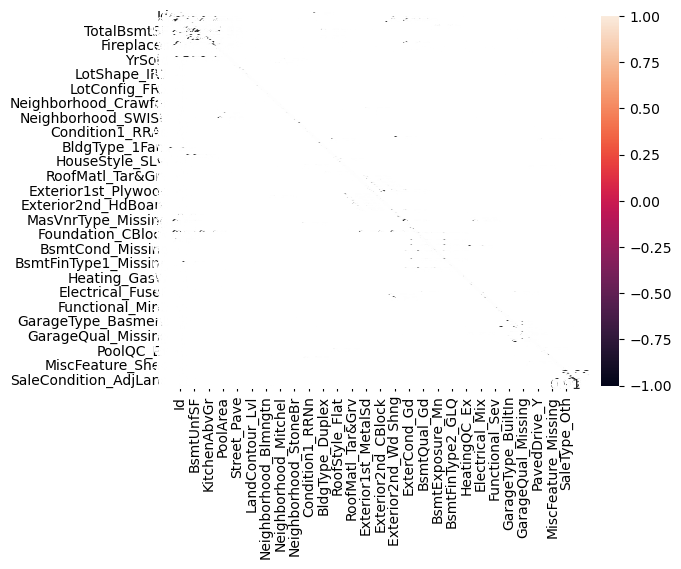

In [46]:
sns.heatmap(df.corr(),annot = True)

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

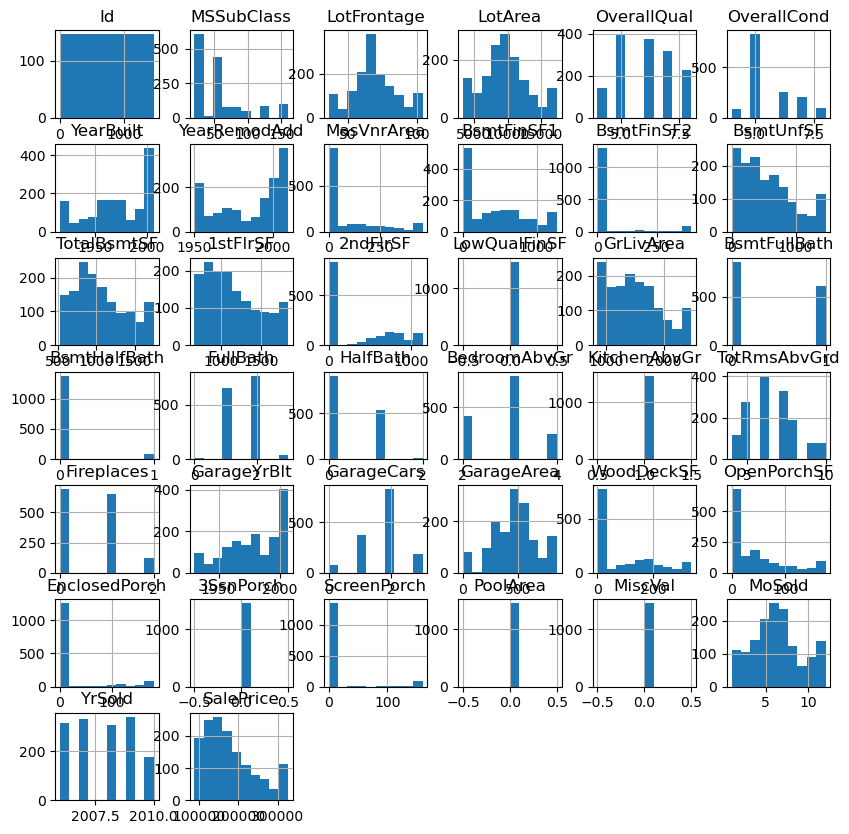

In [47]:
df.hist(figsize = (10,10))

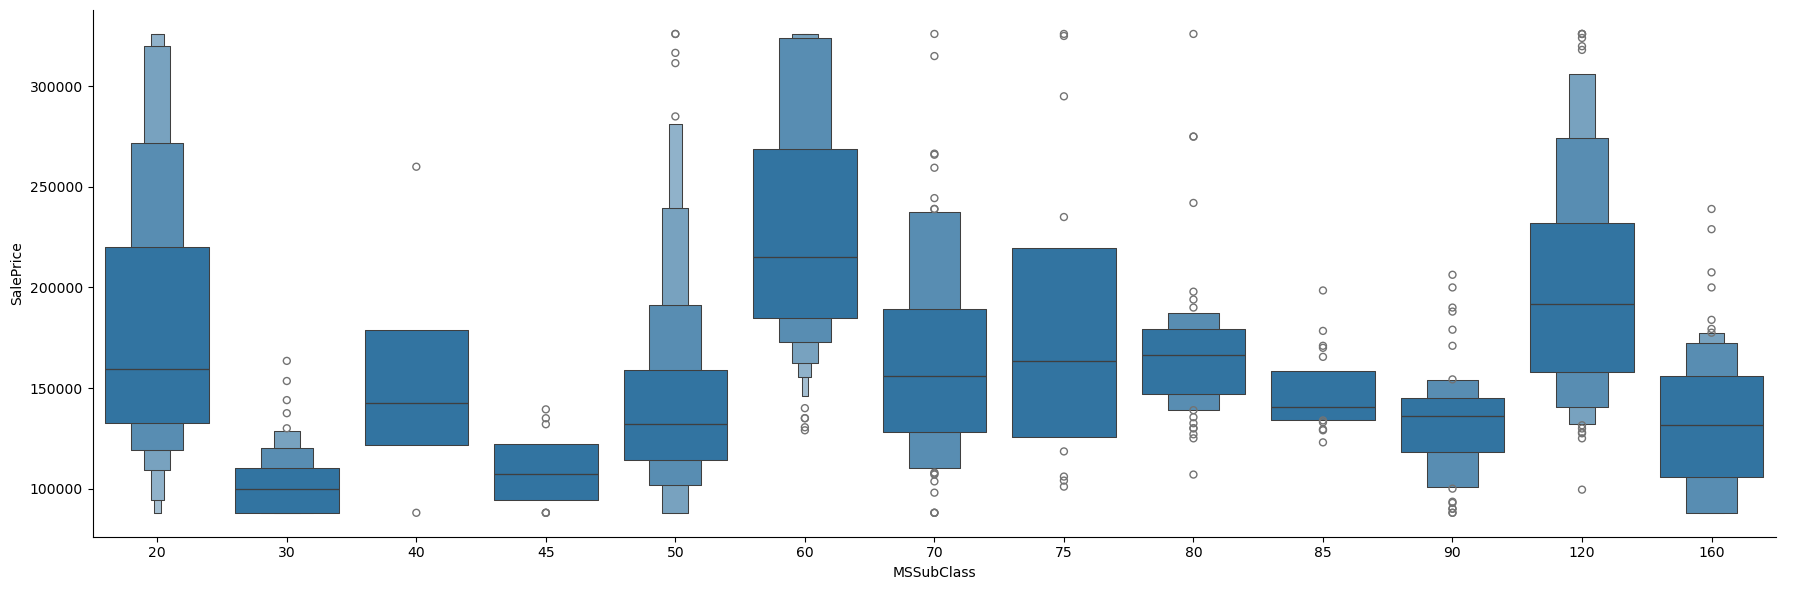

In [50]:
sns.catplot(y = 'SalePrice',x = 'MSSubClass',data = df.sort_values('SalePrice',ascending = False),kind='boxen',height = 6,aspect=3)

C:\Users\RAKESH\AppData\Local\Temp\ipykernel_22268\1652613327.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['SalePrice'], bins=30)


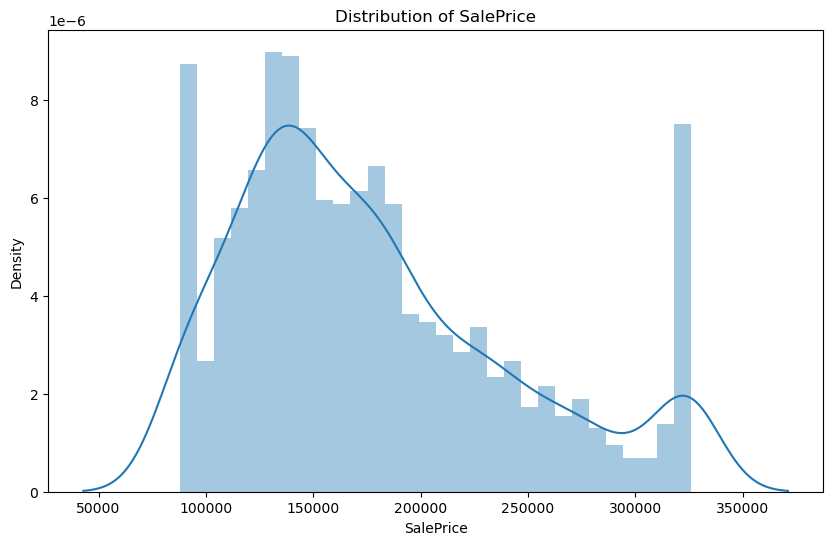

In [52]:
plt.figure(figsize=(10, 6))
sns.distplot(df['SalePrice'], bins=30)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.show()

Text(0, 0.5, 'y_pred')

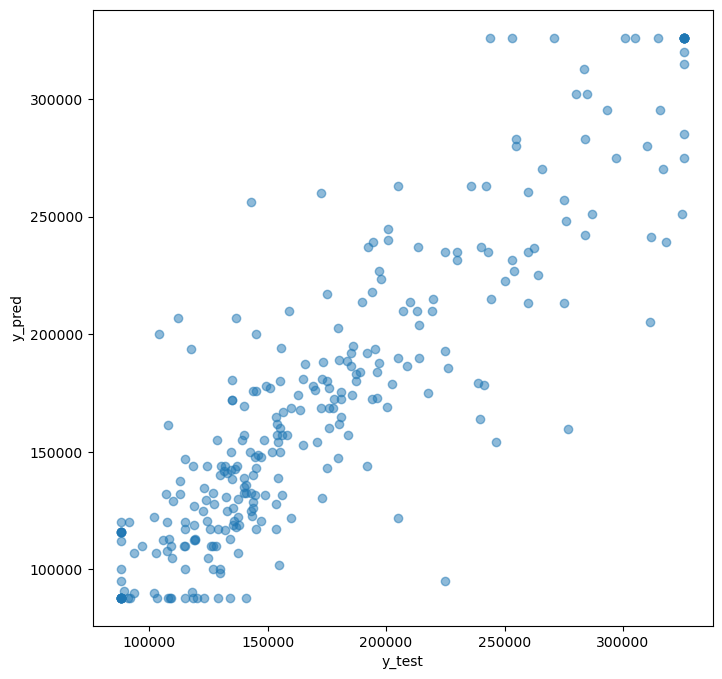

In [161]:
plt.figure(figsize = (8,8))
plt.scatter(y_test,y_pred,alpha = 0.5)
plt.xlabel('y_test')
plt.ylabel('y_pred')

In [63]:
target_variable = 'SalePrice'
y = df[target_variable]
x = df.drop(target_variable, axis=1)

## Train a model

In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [67]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler = StandardScaler()

In [71]:
numerical_features = x.select_dtypes(include=np.number).columns

In [73]:
x[numerical_features] = scaler.fit_transform(x[numerical_features])

In [75]:
print("\nData splitting complete:")
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Data splitting complete:
x_train shape: (1168, 304)
x_test shape: (292, 304)
y_train shape: (1168,)
y_test shape: (292,)


In [77]:
import random

In [79]:
np.random.seed(42)
random.seed(42)

## RandomForestRegressor model

In [82]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()

In [84]:
model.fit(x_train,y_train)

RandomForestRegressor()

In [85]:
y_pred = model.predict(x_test)

## Evaluate

In [87]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [88]:
mean_absolute_error(y_test,y_pred)

14180.716506849314

In [89]:
mean_squared_error(y_test,y_pred)

386059784.26135004

In [95]:
r2_score(y_test,y_pred)

0.9130975396914108

## DecisionTree Regressor

In [98]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()

In [100]:
model.fit(x_train,y_train)

DecisionTreeRegressor()

In [102]:
y_pred = model.predict(x_test)

In [104]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [106]:
mean_absolute_error(y_test,y_pred)

21473.719178082192

In [108]:
mean_squared_error(y_test,y_pred)

968440579.7397261

In [110]:
r2_score(y_test,y_pred)

0.7820030148877536

## GridSearchCV

In [113]:
from sklearn.model_selection import GridSearchCV

In [115]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Define the model
model = DecisionTreeRegressor()

# Define the parameter grid (notice the 'model__' prefix is not needed here, just use the parameter names)
param_grid = {
    'criterion': ['squared_error', 'friedman_mse'],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,             # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1         # Use all processors
)

# Fit it to your training data
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse'],
                         'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

In [116]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [117]:
print("Best score:", grid_search.best_score_)

Best score: -900934536.6773069


In [118]:
best_model = grid_search.best_estimator_
y_pred_hp = best_model.predict(x_test)

In [119]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [120]:
mean_absolute_error(y_test,y_pred)

21473.719178082192

In [121]:
mean_squared_error(y_test,y_pred)

968440579.7397261

In [122]:
r2_score(y_test,y_pred)

0.7820030148877536

## XGBRegressor 

In [124]:
from xgboost import XGBRegressor
xgb = XGBRegressor()

In [125]:
xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [135]:
xgb_pred = xgb.predict(x_test)

In [138]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [140]:
mean_absolute_error(y_test,y_pred)

21473.719178082192

In [142]:
mean_squared_error(y_test,y_pred)

968440579.7397261

In [144]:
r2_score(y_test,y_pred)

0.7820030148877536

## GreadientBoostingRegressor

In [147]:
from sklearn.ensemble import GradientBoostingRegressor
model_gbr = GradientBoostingRegressor()

In [149]:
model_gbr.fit(x_train,y_train)

GradientBoostingRegressor()

In [150]:
y_pred_gbr = model_gbr.predict(x_test)

In [153]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [155]:
mean_absolute_error(y_test,y_pred)

21473.719178082192

In [157]:
mean_squared_error(y_test,y_pred)

968440579.7397261

In [159]:
r2_score(y_test,y_pred)

0.7820030148877536